# Premier League Match Prediction - LightGBM Tuning

## Objective

This notebook tunes LightGBM with expanding chronological validation folds, then compares tuned LightGBM against logistic regression on the final 2025_2026 holdout season.

The search supports two objectives:

- Macro F1 for class-label performance.
- Log loss for probability quality.

## 1. Modeling Rules

The model uses only pre-match engineered features. Odds are included because they are pre-match market information.

Validation folds:

- Train through 2020_2021, validate 2021_2022
- Train through 2021_2022, validate 2022_2023
- Train through 2022_2023, validate 2023_2024
- Train through 2023_2024, validate 2024_2025

The 2025_2026 season is reserved for final testing.

## 2. Load Data and Features

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
N_ITER = 30

DATA_PATH = Path("../data/processed/epl_features.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 3800
Columns: 336


,MatchID,Season,Date,Time,HomeTeam,AwayTeam,target_result,target_result_encoded,target_home_win,target_draw,target_away_win,FTHG,FTAG,FTR,market_home_odds,market_draw_odds,market_away_odds,market_home_implied_prob,market_draw_implied_prob,market_away_implied_prob,market_overround,market_home_norm_prob,market_draw_norm_prob,market_away_norm_prob,home_overall_points_last_5,home_overall_win_last_5,home_overall_draw_last_5,home_overall_loss_last_5,home_overall_goals_for_last_5,home_overall_goals_against_last_5,home_overall_goal_diff_last_5,home_overall_shots_for_last_5,home_overall_shots_against_last_5,home_overall_shot_diff_last_5,home_overall_sot_for_last_5,home_overall_sot_against_last_5,home_overall_sot_diff_last_5,home_overall_corners_for_last_5,home_overall_corners_against_last_5,home_overall_corner_diff_last_5,home_overall_fouls_for_last_5,home_overall_fouls_against_last_5,home_overall_yellow_for_last_5,home_overall_yellow_against_last_5,home_overall_red_for_last_5,home_overall_red_against_last_5,home_overall_points_last_10,home_overall_win_last_10,home_overall_draw_last_10,home_overall_loss_last_10,home_overall_goals_for_last_10,home_overall_goals_against_last_10,home_overall_goal_diff_last_10,home_overall_shots_for_last_10,home_overall_shots_against_last_10,home_overall_shot_diff_last_10,home_overall_sot_for_last_10,home_overall_sot_against_last_10,home_overall_sot_diff_last_10,home_overall_corners_for_last_10,home_overall_corners_against_last_10,home_overall_corner_diff_last_10,home_overall_fouls_for_last_10,home_overall_fouls_against_last_10,home_overall_yellow_for_last_10,home_overall_yellow_against_last_10,home_overall_red_for_last_10,home_overall_red_against_last_10,home_venue_points_last_5,home_venue_win_last_5,home_venue_goals_for_last_5,home_venue_goals_against_last_5,home_venue_goal_diff_last_5,home_venue_shots_for_last_5,home_venue_shots_against_last_5,home_venue_sot_for_last_5,home_venue_sot_against_last_5,home_team_matches_played_before,home_days_since_last_match,home_long_gap_since_last_match,home_low_history_flag,home_season_matches_played_before,home_season_points,home_season_points_per_match,home_season_win,home_season_win_per_match,home_season_draw,home_season_draw_per_match,home_season_loss,home_season_loss_per_match,home_season_goals_for,home_season_goals_for_per_match,home_season_goals_against,home_season_goals_against_per_match,home_season_goal_diff,home_season_goal_diff_per_match,home_season_shots_for,home_season_shots_for_per_match,home_season_shots_against,home_season_shots_against_per_match,home_season_shot_diff,home_season_shot_diff_per_match,home_season_sot_for,home_season_sot_for_per_match,home_season_sot_against,home_season_sot_against_per_match,home_season_sot_diff,home_season_sot_diff_per_match,home_season_corners_for,home_season_corners_for_per_match,home_season_corners_against,home_season_corners_against_per_match,home_season_corner_diff,home_season_corner_diff_per_match,home_season_fouls_for,home_season_fouls_for_per_match,home_season_fouls_against,home_season_fouls_against_per_match,home_season_yellow_for,home_season_yellow_for_per_match,home_season_yellow_against,home_season_yellow_against_per_match,home_season_red_for,home_season_red_for_per_match,home_season_red_against,home_season_red_against_per_match,home_venue_season_matches_played_before,home_venue_season_points,home_venue_season_points_per_match,home_venue_season_win,home_venue_season_win_per_match,home_venue_season_goals_for,home_venue_season_goals_for_per_match,home_venue_season_goals_against,home_venue_season_goals_against_per_match,home_venue_season_goal_diff,home_venue_season_goal_diff_per_match,home_venue_season_shots_for,home_venue_season_shots_for_per_match,home_venue_season_shots_against,home_venue_season_shots_against_per_match,home_venue_season_sot_for,home_venue_season_sot_for_per_match,home_venue_season_sot_against,home_venue_season_sot_against_per_match,away_overall_points_last_5,away_overall_win_last_5,away_overal

In [2]:
excluded_cols = [
    "MatchID", "Season", "Date", "Time", "HomeTeam", "AwayTeam",
    "target_result", "target_result_encoded", "target_home_win", "target_draw", "target_away_win",
    "FTHG", "FTAG", "FTR",
]

feature_cols = df[[col for col in df.columns if col not in excluded_cols]].select_dtypes(include=["number", "bool"]).columns.tolist()

X = df[feature_cols]
y = df["target_result_encoded"]

print("Feature count:", len(feature_cols))
print(y.value_counts(normalize=True).sort_index().round(3))

Feature count: 322
target_result_encoded
0    0.446
1    0.232
2    0.321
Name: proportion, dtype: float64


## 3. Expanding Validation Folds

In [3]:
validation_folds = [
    {"train_through": "2020_2021", "valid_season": "2021_2022"},
    {"train_through": "2021_2022", "valid_season": "2022_2023"},
    {"train_through": "2022_2023", "valid_season": "2023_2024"},
    {"train_through": "2023_2024", "valid_season": "2024_2025"},
]

fold_summary = []
for fold in validation_folds:
    train_mask = df["Season"] <= fold["train_through"]
    valid_mask = df["Season"] == fold["valid_season"]
    fold_summary.append({
        **fold,
        "train_rows": int(train_mask.sum()),
        "valid_rows": int(valid_mask.sum()),
    })

pd.DataFrame(fold_summary)

,train_through,valid_season,train_rows,valid_rows
0,2020_2021,2021_2022,1900,380
1,2021_2022,2022_2023,2280,380
2,2022_2023,2023_2024,2660,380
3,2023_2024,2024_2025,3040,380


## 4. Evaluation Helpers

In [4]:
target_labels = {0: "Home Win", 1: "Draw", 2: "Away Win"}


def evaluate_predictions(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1, 2]),
    }


def evaluate_model(model, X_eval, y_eval):
    return evaluate_predictions(
        y_eval,
        model.predict(X_eval),
        model.predict_proba(X_eval),
    )


def plot_confusion_matrix(model, X_eval, y_eval, title):
    cm = confusion_matrix(y_eval, model.predict(X_eval), labels=[0, 1, 2])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[target_labels[i] for i in [0,1,2]], yticklabels=[target_labels[i] for i in [0,1,2]])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 5. Logistic Regression Cross-Fold Baseline

In [5]:
def build_logistic_model():
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


logistic_fold_results = []

for fold in validation_folds:
    train_mask = df["Season"] <= fold["train_through"]
    valid_mask = df["Season"] == fold["valid_season"]

    model = build_logistic_model()
    model.fit(X.loc[train_mask], y.loc[train_mask])

    logistic_fold_results.append({
        "model": "Logistic Regression",
        **fold,
        **evaluate_model(model, X.loc[valid_mask], y.loc[valid_mask]),
    })

logistic_fold_results = pd.DataFrame(logistic_fold_results)
logistic_fold_results.round(4)

,model,train_through,valid_season,accuracy,macro_f1,log_loss
0,Logistic Regression,2020_2021,2021_2022,0.4316,0.4175,1.2195
1,Logistic Regression,2021_2022,2022_2023,0.4079,0.3960,1.1657
2,Logistic Regression,2022_2023,2023_2024,0.5105,0.4615,1.0245
3,Logistic Regression,2023_2024,2024_2025,0.4763,0.4514,1.0518


In [6]:
logistic_cv_summary = logistic_fold_results[["accuracy", "macro_f1", "log_loss"]].mean().to_dict()
logistic_cv_summary

{'accuracy': 0.4565789473684211,
 'macro_f1': 0.4316245755814067,
 'log_loss': 1.1153908090244746}

## 6. LightGBM Random Search With Expanding Folds

In [7]:
param_dist = {
    "n_estimators": [150, 250, 400, 600, 800],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "num_leaves": [5, 7, 9, 15, 21, 31],
    "max_depth": [2, 3, 4, 5, -1],
    "min_child_samples": [10, 20, 30, 50, 75, 100, 150],
    "subsample": [0.65, 0.75, 0.85, 0.95, 1.0],
    "colsample_bytree": [0.55, 0.65, 0.75, 0.85, 0.95, 1.0],
    "reg_alpha": [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    "min_split_gain": [0.0, 0.01, 0.05, 0.1],
}

sampled_params = list(ParameterSampler(param_dist, n_iter=N_ITER, random_state=RANDOM_STATE))
len(sampled_params)

30

In [8]:
def build_lgbm(params):
    return LGBMClassifier(
        objective="multiclass",
        num_class=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1,
        **params,
    )


tuning_rows = []

for iteration, params in enumerate(sampled_params, start=1):
    fold_metrics = []

    for fold in validation_folds:
        train_mask = df["Season"] <= fold["train_through"]
        valid_mask = df["Season"] == fold["valid_season"]

        model = build_lgbm(params)
        model.fit(
            X.loc[train_mask],
            y.loc[train_mask],
            eval_set=[(X.loc[valid_mask], y.loc[valid_mask])],
            eval_metric="multi_logloss",
            callbacks=[early_stopping(stopping_rounds=30, verbose=False), log_evaluation(period=0)],
        )
        metrics = evaluate_model(model, X.loc[valid_mask], y.loc[valid_mask])
        fold_metrics.append({**fold, "best_iteration": model.best_iteration_, **metrics})

    fold_metrics = pd.DataFrame(fold_metrics)
    tuning_rows.append({
        "iteration": iteration,
        **params,
        "mean_best_iteration": fold_metrics["best_iteration"].mean(),
        "mean_accuracy": fold_metrics["accuracy"].mean(),
        "mean_macro_f1": fold_metrics["macro_f1"].mean(),
        "mean_log_loss": fold_metrics["log_loss"].mean(),
    })

    if iteration % 10 == 0:
        print(f"Completed {iteration} / {N_ITER} configurations")

tuning_results = pd.DataFrame(tuning_rows)
tuning_results.sort_values(["mean_macro_f1", "mean_log_loss"], ascending=[False, True]).head(10).round(4)

Completed 10 / 30 configurations
Completed 20 / 30 configurations
Completed 30 / 30 configurations


,iteration,subsample,reg_lambda,reg_alpha,num_leaves,n_estimators,min_split_gain,min_child_samples,max_depth,learning_rate,colsample_bytree,mean_best_iteration,mean_accuracy,mean_macro_f1,mean_log_loss
27,28,0.95,1.00,1.00,9,150,0.01,30,2,0.03,0.55,99.00,0.5289,0.4975,0.9808
20,21,0.85,2.00,2.00,31,600,0.05,100,2,0.03,1.00,169.25,0.5276,0.4968,0.9794
21,22,0.65,0.05,2.00,21,800,0.05,20,2,0.08,0.65,93.00,0.5368,0.4952,0.9770
7,8,1.00,5.00,0.10,7,250,0.05,150,2,0.05,0.65,74.00,0.5263,0.4950,0.9811
8,9,0.85,0.01,1.00,15,600,0.01,30,2,0.05,0.85,95.25,0.5283,0.4927,0.9798
18,19,0.95,2.00,0.00,7,800,0.00,75,3,0.05,0.65,47.75,0.5309,0.4922,0.9808
9,10,0.65,0.01,0.50,5,800,0.10,50,2,0.05,0.85,76.25,0.5263,0.4912,0.9794
29,30,0.65,0.00,0.00,7,150,0.00,150,2,0.03,0.85,93.25,0.5197,0.4893,0.9819
23,24,0.75,2.00,0.05,5,400,0.00,75,4,0.01,1.00,236.75,0.5263,0.4889,0.9817
25,26,0.65,2.00,2.00,21,250,0.10,75,3,0.08,0.75,38.00,0.5243,0.4866,0.9850


## 7. Select Best Parameters for Two Objectives

In [9]:
best_f1_row = tuning_results.sort_values(["mean_macro_f1", "mean_log_loss"], ascending=[False, True]).iloc[0]
best_logloss_row = tuning_results.sort_values(["mean_log_loss", "mean_macro_f1"], ascending=[True, False]).iloc[0]

summary_rows = []
for objective, row in [("macro_f1", best_f1_row), ("log_loss", best_logloss_row)]:
    summary_rows.append({
        "objective": objective,
        "iteration": int(row["iteration"]),
        "mean_accuracy": row["mean_accuracy"],
        "mean_macro_f1": row["mean_macro_f1"],
        "mean_log_loss": row["mean_log_loss"],
        "mean_best_iteration": row["mean_best_iteration"],
    })

pd.DataFrame(summary_rows).round(4)

,objective,iteration,mean_accuracy,mean_macro_f1,mean_log_loss,mean_best_iteration
0,macro_f1,28,0.5289,0.4975,0.9808,99.00
1,log_loss,15,0.5441,0.4847,0.9746,76.25


## 8. Final Holdout Test Evaluation

In [10]:
def params_from_row(row):
    params = {key: row[key] for key in param_dist.keys()}
    for key in ["n_estimators", "num_leaves", "max_depth", "min_child_samples"]:
        params[key] = int(params[key])
    params["n_estimators"] = max(20, int(round(row["mean_best_iteration"])))
    return params


final_train_mask = df["Season"] <= "2024_2025"
test_mask = df["Season"] == "2025_2026"

final_results = []
final_models = {}

logistic_final = build_logistic_model()
logistic_final.fit(X.loc[final_train_mask], y.loc[final_train_mask])
final_models["Logistic Regression"] = logistic_final
final_results.append({
    "model": "Logistic Regression",
    "selection_objective": "baseline",
    **evaluate_model(logistic_final, X.loc[test_mask], y.loc[test_mask]),
})

for objective, row in [("macro_f1", best_f1_row), ("log_loss", best_logloss_row)]:
    params = params_from_row(row)
    model = build_lgbm(params)
    model.fit(X.loc[final_train_mask], y.loc[final_train_mask])
    name = f"LightGBM selected by {objective}"
    final_models[name] = model
    final_results.append({
        "model": name,
        "selection_objective": objective,
        **evaluate_model(model, X.loc[test_mask], y.loc[test_mask]),
    })

final_results = pd.DataFrame(final_results).sort_values("macro_f1", ascending=False)
final_results.round(4)

,model,selection_objective,accuracy,macro_f1,log_loss
1,LightGBM selected by macro_f1,macro_f1,0.4316,0.4187,1.0419
0,Logistic Regression,baseline,0.4158,0.4173,1.1604
2,LightGBM selected by log_loss,log_loss,0.4368,0.4105,1.0371


## 9. Test Confusion Matrix for Best Final Macro F1

Best final model by test macro F1: LightGBM selected by macro_f1


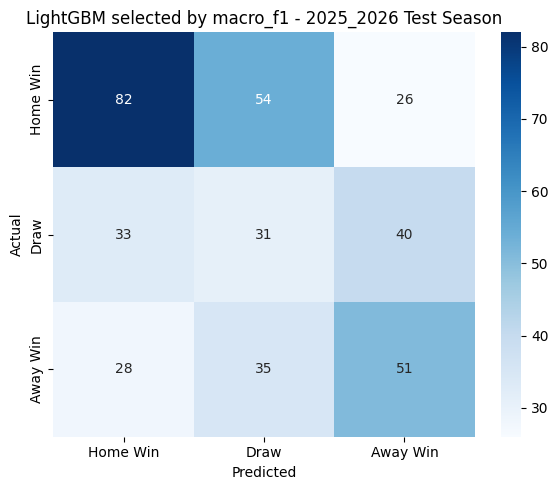

In [11]:
best_final_name = final_results.iloc[0]["model"]
best_final_model = final_models[best_final_name]

print("Best final model by test macro F1:", best_final_name)

plot_confusion_matrix(
    best_final_model,
    X.loc[test_mask],
    y.loc[test_mask],
    title=f"{best_final_name} - 2025_2026 Test Season",
)

## 10. LightGBM Feature Importance

In [12]:
lgbm_names = [name for name in final_models if name.startswith("LightGBM")]
importance_model_name = lgbm_names[0]
importance_model = final_models[importance_model_name]

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
0,market_home_odds,70
7,market_home_norm_prob,57
1,market_draw_odds,47
8,market_draw_norm_prob,40
9,market_away_norm_prob,39
3,market_home_implied_prob,33
121,home_venue_season_goal_diff,28
275,diff_season_shots_against_per_match,24
5,market_away_implied_prob,18
277,diff_season_sot_against_per_match,18


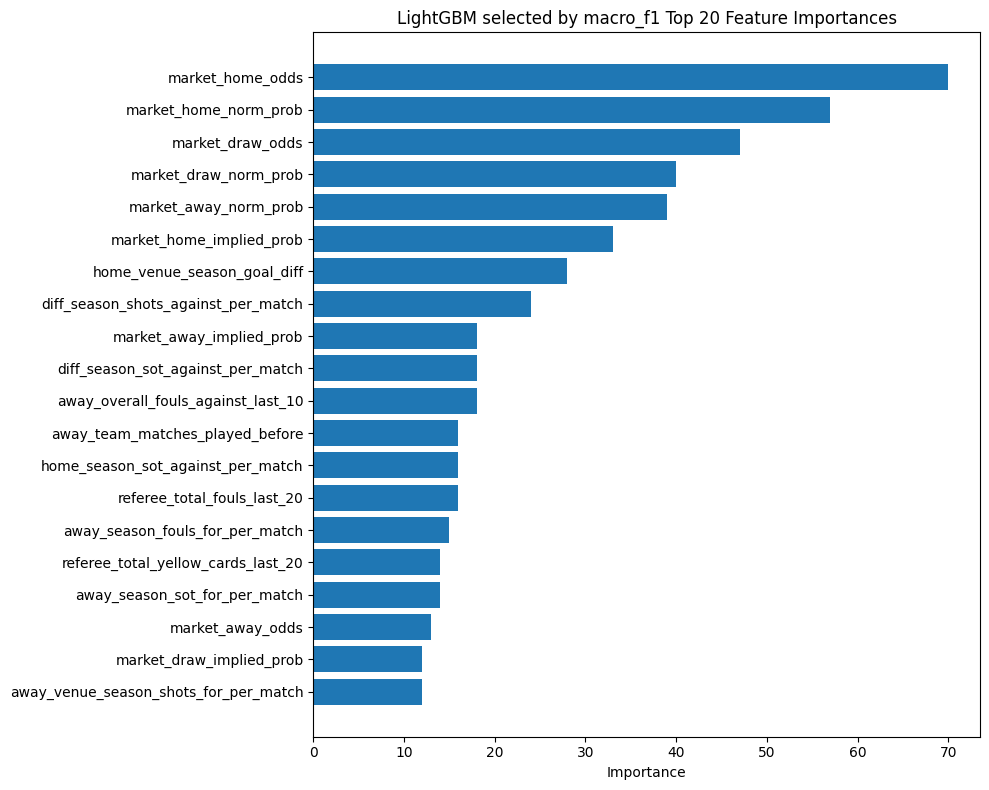

In [13]:
top_importance = importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title(f"{importance_model_name} Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 11. Summary

This notebook uses expanding validation folds to make LightGBM tuning less dependent on a single season. It selects LightGBM settings for both macro F1 and log loss, then compares those tuned models with logistic regression on the untouched 2025_2026 test season.